In [ ]:
# Import required libraries
import odc.stac
import pandas as pd
import planetary_computer
import pystac_client
import xarray as xr
import panel as pn

# Enable Panel for interactive visualizations
pn.extension()

In [ ]:
# Connect to Planetary Computer Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [ ]:
# Corrected Query for Sentinel-1 RTC or Sentinel-2 L2A with Cloud Cover Filter for August 2024
bbox = [51.2196, 35.5384, 51.6759, 35.8456]  # Tehran bounding box
datetime = "2024-08-01/2024-08-31"  # August 2024
cloudy_less_than = 10  # Percent cloud cover threshold (only for Sentinel-2)

# Search Sentinel-2 L2A with cloud cover filter
search_s2 = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloudy_less_than}},  # Filter for low cloud cover
)
s2_items = search_s2.item_collection()

# Search Sentinel-1 RTC
search_s1 = catalog.search(
    collections=["sentinel-1-rtc"],
    bbox=bbox,
    datetime=datetime,
)
s1_items = search_s1.item_collection()

# Print Results for Sentinel-2
print(f"Sentinel-2 Returned {len(s2_items)} Items:")
if s2_items:
    for item in s2_items:
        print(item.id)
else:
    print("No Sentinel-2 items found with the current filter.")

# Print Results for Sentinel-1
print(f"Sentinel-1 Returned {len(s1_items)} Items:")
if s1_items:
    for item in s1_items:
        print(item.id)
else:
    print("No Sentinel-1 items found with the current filter.")

Sentinel-2 Returned 6 Items:
S2B_MSIL2A_20240829T071619_R006_T39SWV_20240829T105244
S2A_MSIL2A_20240824T071621_R006_T39SWV_20240824T124245
S2B_MSIL2A_20240819T071619_R006_T39SWV_20240819T104209
S2A_MSIL2A_20240814T071621_R006_T39SWV_20240814T121757
S2B_MSIL2A_20240809T071619_R006_T39SWV_20240809T102208
S2A_MSIL2A_20240804T071621_R006_T39SWV_20240804T124100
Sentinel-1 Returned 6 Items:
S1A_IW_GRDH_1SDV_20240828T023725_20240828T023750_055407_06C207_rtc
S1A_IW_GRDH_1SDV_20240827T143617_20240827T143642_055400_06C1D6_rtc
S1A_IW_GRDH_1SDV_20240816T023724_20240816T023749_055232_06BB8D_rtc
S1A_IW_GRDH_1SDV_20240815T143616_20240815T143641_055225_06BB57_rtc
S1A_IW_GRDH_1SDV_20240810T142807_20240810T142832_055152_06B8AA_rtc
S1A_IW_GRDH_1SDV_20240804T023725_20240804T023750_055057_06B52A_rtc


In [ ]:
# Sentinel-1 Query and Median Composite
s1_bands_of_interest = ["vv", "vh"]

# Load all selected items (tiles) into a list of datasets for Sentinel-1
s1_datasets = []
for item in s1_items:
    ds_tile = odc.stac.stac_load(
        [item],
        bands=s1_bands_of_interest,
        bbox=bbox,
        chunks={},  # Enable Dask for memory efficiency
    )
    s1_datasets.append(ds_tile)

# Merge all datasets into one composite dataset
s1_merged = xr.concat(s1_datasets, dim="time")

# Create a composite by taking the median across the `time` dimension
s1_composite = s1_merged.median(dim="time")

In [ ]:
# Sentinel-2 Query and Median Composite
s2_bands_of_interest = ["red", "green", "blue"]

# Load all selected items (tiles) into a list of datasets for Sentinel-2
s2_datasets = []
for item in s2_items:
    ds_tile = odc.stac.stac_load(
        [item],
        bands=s2_bands_of_interest,
        bbox=bbox,
        chunks={},  # Enable Dask for memory efficiency
    )
    s2_datasets.append(ds_tile)

# Merge all datasets into one composite dataset
s2_merged = xr.concat(s2_datasets, dim="time")

# Create a composite by taking the median across the `time` dimension
s2_composite = s2_merged.median(dim="time")

In [ ]:
# Resample Sentinel-2 to match Sentinel-1 resolution (if needed)
s2_resampled = s2_composite.interp_like(s1_composite)

# Stack Sentinel-1 and Sentinel-2 composites into a single dataset
fused_dataset = xr.merge([s1_composite, s2_resampled])

# Check the structure of the fused dataset
print(fused_dataset)

<xarray.Dataset> Size: 398MB
Dimensions:      (y: 3427, x: 4145)
Coordinates:
  * y            (y) float64 27kB 3.967e+06 3.967e+06 ... 3.933e+06 3.933e+06
  * x            (x) float64 33kB 5.198e+05 5.198e+05 ... 5.613e+05 5.613e+05
    spatial_ref  int32 4B 32639
Data variables:
    vv           (y, x) float32 57MB dask.array<chunksize=(2150, 2600), meta=np.ndarray>
    vh           (y, x) float32 57MB dask.array<chunksize=(2150, 2600), meta=np.ndarray>
    red          (y, x) float32 57MB dask.array<chunksize=(3427, 4145), meta=np.ndarray>
    green        (y, x) float32 57MB dask.array<chunksize=(3427, 4145), meta=np.ndarray>
    blue         (y, x) float32 57MB dask.array<chunksize=(3427, 4145), meta=np.ndarray>
    nir          (y, x) float32 57MB dask.array<chunksize=(3427, 4145), meta=np.ndarray>
    swir16       (y, x) float32 57MB dask.array<chunksize=(3427, 4145), meta=np.ndarray>


In [ ]:
# Convert Sentinel-1 composite dataset to DataArray
s1_da = s1_composite.to_array(dim="band").compute()

# Add attributes from the first Sentinel-1 item
s1_da.attrs = s1_items[0].properties
s1_da.attrs["crs"] = f"epsg:{s1_items[0].properties['proj:epsg']}"

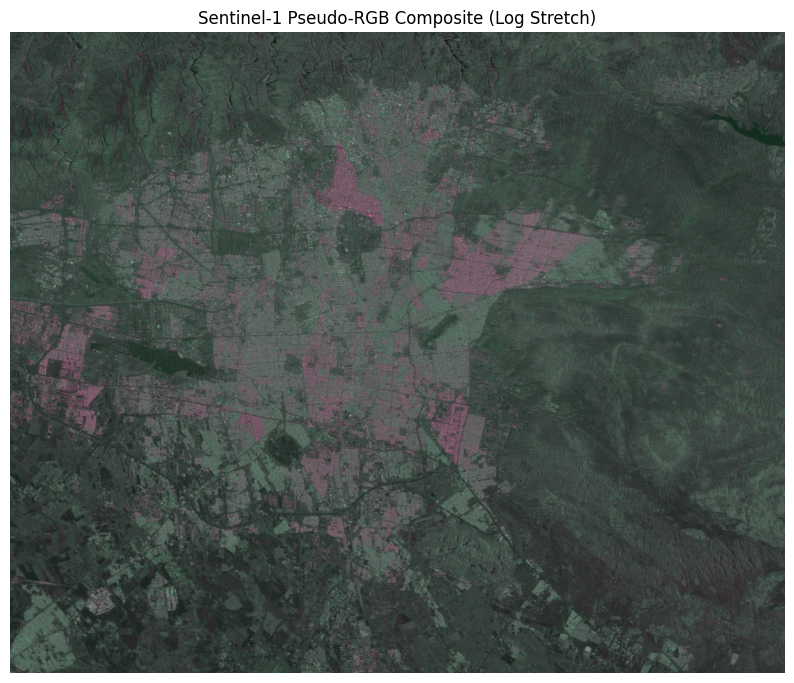

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract VV and VH polarizations
vv = s1_da.sel(band="vv").values
vh = s1_da.sel(band="vh").values

# Replace non-positive values with NaN for log transformation
vv = np.where(vv <= 0, np.nan, vv)
vh = np.where(vh <= 0, np.nan, vh)

# Apply log transformation
vv_log = np.log10(vv + 1e-6)
vh_log = np.log10(vh + 1e-6)

# Normalize log-transformed bands
vv_log_norm = (vv_log - np.nanmin(vv_log)) / (np.nanmax(vv_log) - np.nanmin(vv_log))
vh_log_norm = (vh_log - np.nanmin(vh_log)) / (np.nanmax(vh_log) - np.nanmin(vh_log))

# Create a pseudo-RGB composite
pseudo_rgb = np.dstack((vv_log_norm, vh_log_norm, (vv_log_norm + vh_log_norm) / 2))

# Plot the Sentinel-1 Pseudo-RGB Composite with Log Stretch
plt.figure(figsize=(10, 10))
plt.imshow(pseudo_rgb)
plt.title("Sentinel-1 Pseudo-RGB Composite (Log Stretch)")
plt.axis("off")
plt.show()


In [ ]:
# Convert Sentinel-2 composite dataset to DataArray
s2_da = s2_composite.to_array(dim="band").compute()

# Add attributes from the first Sentinel-2 item
s2_da.attrs = s2_items[0].properties
s2_da.attrs["crs"] = f"epsg:{s2_items[0].properties['proj:epsg']}"

/home/nissim/snap/code/176/.local/share/virtualenvs/musa-650-spring-2025-BY6WbUPk/lib/python3.12/site-packages/rasterio/warp.py:344: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _reproject(


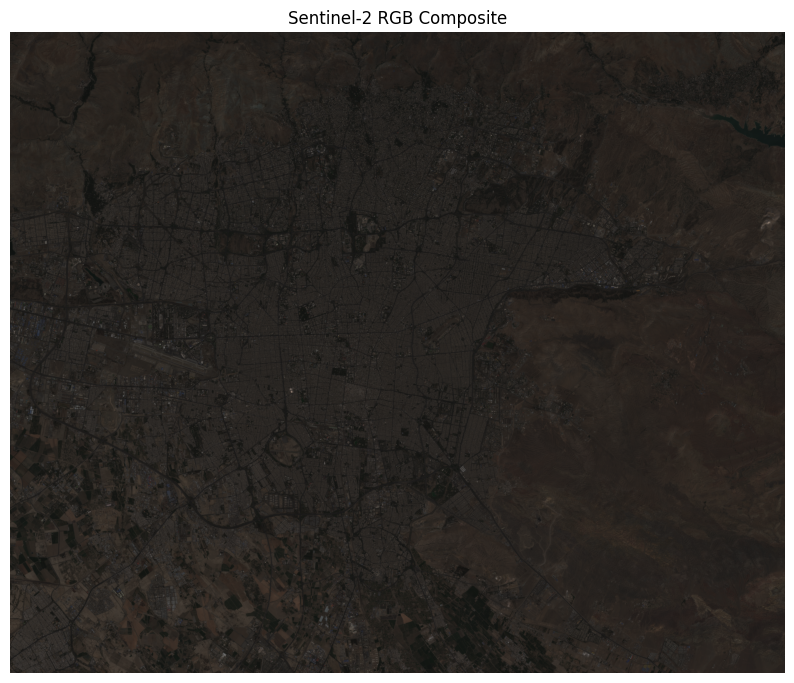

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract RGB bands for Sentinel-2
red = s2_da.sel(band="red").values
green = s2_da.sel(band="green").values
blue = s2_da.sel(band="blue").values

# Normalize bands, handling NaN values
red_norm = red / np.nanmax(red)
green_norm = green / np.nanmax(green)
blue_norm = blue / np.nanmax(blue)

# Stack into an RGB image
s2_rgb_image = np.dstack((red_norm, green_norm, blue_norm))

# Plot the Sentinel-2 RGB Composite
plt.figure(figsize=(10, 10))
plt.imshow(s2_rgb_image)
plt.title("Sentinel-2 RGB Composite")
plt.axis("off")
plt.show()

In [ ]:
# Convert fused dataset to DataArray
fused_da = fused_dataset.to_array(dim="band").compute()

# Add attributes (taking from Sentinel-1 as base, modify as needed)
fused_da.attrs = s1_items[0].properties
fused_da.attrs["crs"] = f"epsg:{s1_items[0].properties['proj:epsg']}"

Reshaped Data Shape: (14204915, 2)
Clustered Image Shape: (3427, 4145)


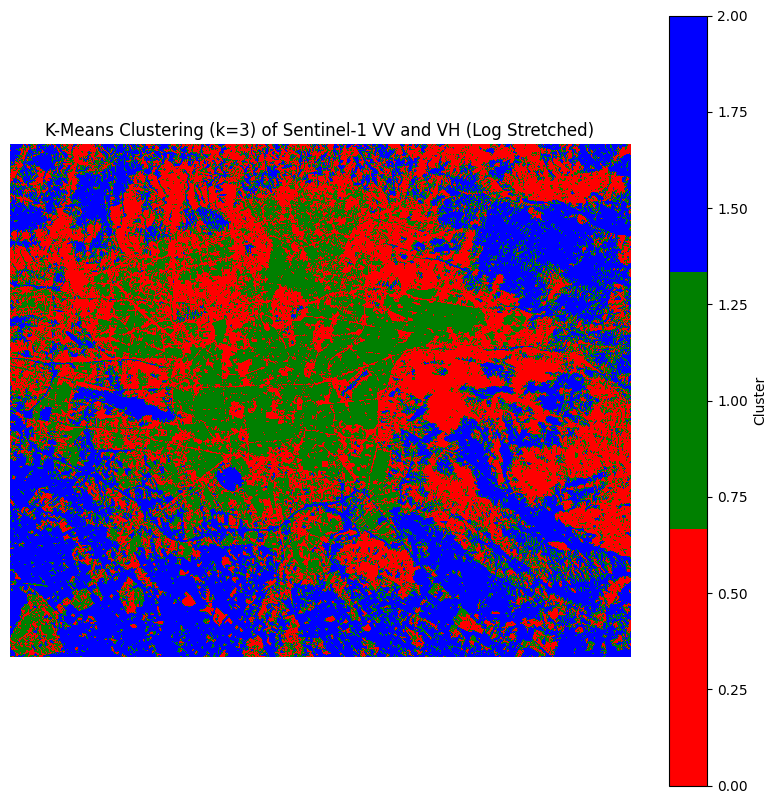

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# Extract VV and VH polarizations
vv = s1_da.sel(band="vv").values
vh = s1_da.sel(band="vh").values

# Replace non-positive values with NaN for log transformation
vv = np.where(vv <= 0, np.nan, vv)
vh = np.where(vh <= 0, np.nan, vh)

# Apply log transformation
vv_log = np.log10(vv + 1e-6)
vh_log = np.log10(vh + 1e-6)

# Normalize log-transformed bands
vv_log_norm = (vv_log - np.nanmin(vv_log)) / (np.nanmax(vv_log) - np.nanmin(vv_log))
vh_log_norm = (vh_log - np.nanmin(vh_log)) / (np.nanmax(vh_log) - np.nanmin(vh_log))

# Stack normalized VV and VH bands into 2D array for clustering
log_data = np.dstack((vv_log_norm, vh_log_norm))
pixels = log_data.reshape(-1, 2)  # Flatten spatial dimensions
print("Reshaped Data Shape:", pixels.shape)  # (num_pixels, 2)

# Handle NaN values by replacing with zero or excluding (optional)
pixels = np.nan_to_num(pixels)

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(pixels)

# Get cluster labels
labels = kmeans.labels_

# Reshape labels back to the original image dimensions
clustered_image = labels.reshape(log_data.shape[0], log_data.shape[1])
print("Clustered Image Shape:", clustered_image.shape)

# Plot the clustered image
plt.figure(figsize=(10, 10))
plt.imshow(clustered_image, cmap=ListedColormap(["red", "green", "blue"]))
plt.title("K-Means Clustering (k=3) of Sentinel-1 VV and VH (Log Stretched)")
plt.axis("off")
plt.colorbar(label="Cluster")
plt.show()


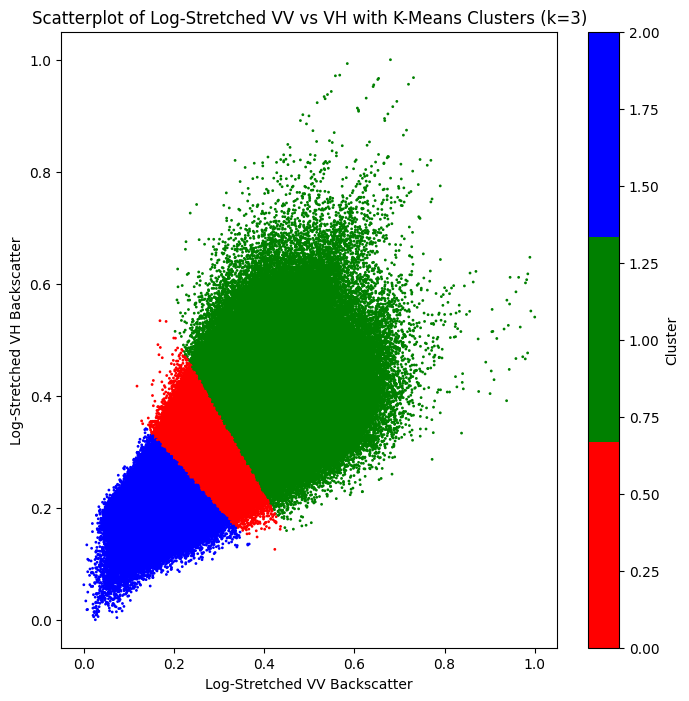

In [ ]:
# Extract log-transformed VV and VH pixel values
vv_pixels = pixels[:, 0]
vh_pixels = pixels[:, 1]

# Scatterplot of VV vs VH with cluster assignments
plt.figure(figsize=(8, 8))
scatter = plt.scatter(vv_pixels, vh_pixels, c=labels, cmap=ListedColormap(["red", "green", "blue"]), s=1)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Log-Stretched VV Backscatter")
plt.ylabel("Log-Stretched VH Backscatter")
plt.title("Scatterplot of Log-Stretched VV vs VH with K-Means Clusters (k=3)")
plt.show()

Reshaped Data Shape: (14204915, 3)
Clustered Image Shape: (3427, 4145)


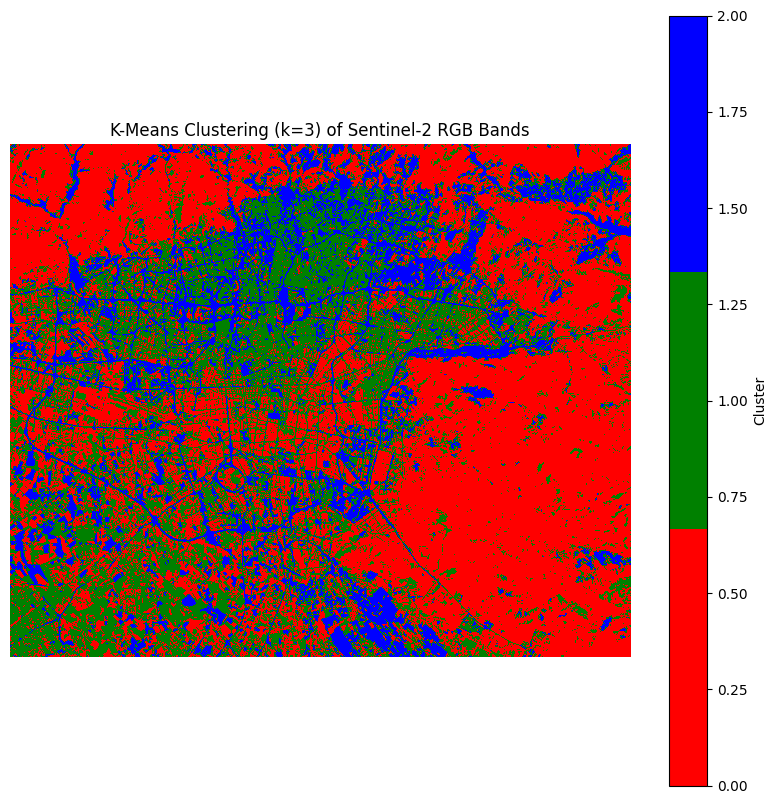

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# Extract RGB bands
red = s2_da.sel(band="red").values
green = s2_da.sel(band="green").values
blue = s2_da.sel(band="blue").values

# Normalize bands
red_norm = (red - np.nanmin(red)) / (np.nanmax(red) - np.nanmin(red))
green_norm = (green - np.nanmin(green)) / (np.nanmax(green) - np.nanmin(green))
blue_norm = (blue - np.nanmin(blue)) / (np.nanmax(blue) - np.nanmin(blue))

# Stack normalized bands into a 3D array (height, width, channels)
rgb_data = np.dstack((red_norm, green_norm, blue_norm))

# Reshape into 2D array (pixels, channels)
pixels = rgb_data.reshape(-1, 3)  # Flatten spatial dimensions
print("Reshaped Data Shape:", pixels.shape)  # (num_pixels, 3)

# Handle NaN values by replacing with zero
pixels = np.nan_to_num(pixels)

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(pixels)

# Get cluster labels
labels = kmeans.labels_

# Reshape labels back to the original image dimensions
clustered_image = labels.reshape(rgb_data.shape[0], rgb_data.shape[1])
print("Clustered Image Shape:", clustered_image.shape)

# Plot the clustered image
plt.figure(figsize=(10, 10))
plt.imshow(clustered_image, cmap=ListedColormap(["red", "green", "blue"]))
plt.title("K-Means Clustering (k=3) of Sentinel-2 RGB Bands")
plt.axis("off")
plt.colorbar(label="Cluster")
plt.show()

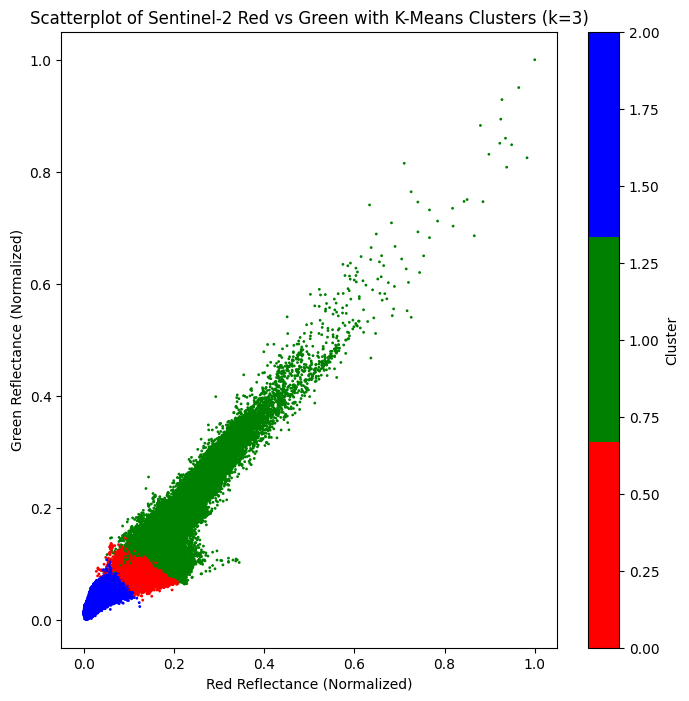

In [ ]:
# Extract RGB pixel values
red_pixels = pixels[:, 0]
green_pixels = pixels[:, 1]
blue_pixels = pixels[:, 2]

# Scatterplot of Red vs Green with cluster assignments
plt.figure(figsize=(8, 8))
scatter = plt.scatter(red_pixels, green_pixels, c=labels, cmap=ListedColormap(["red", "green", "blue"]), s=1)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Red Reflectance (Normalized)")
plt.ylabel("Green Reflectance (Normalized)")
plt.title("Scatterplot of Sentinel-2 Red vs Green with K-Means Clusters (k=3)")
plt.show()

Clustered Image Shape for k=3: (3427, 4145)


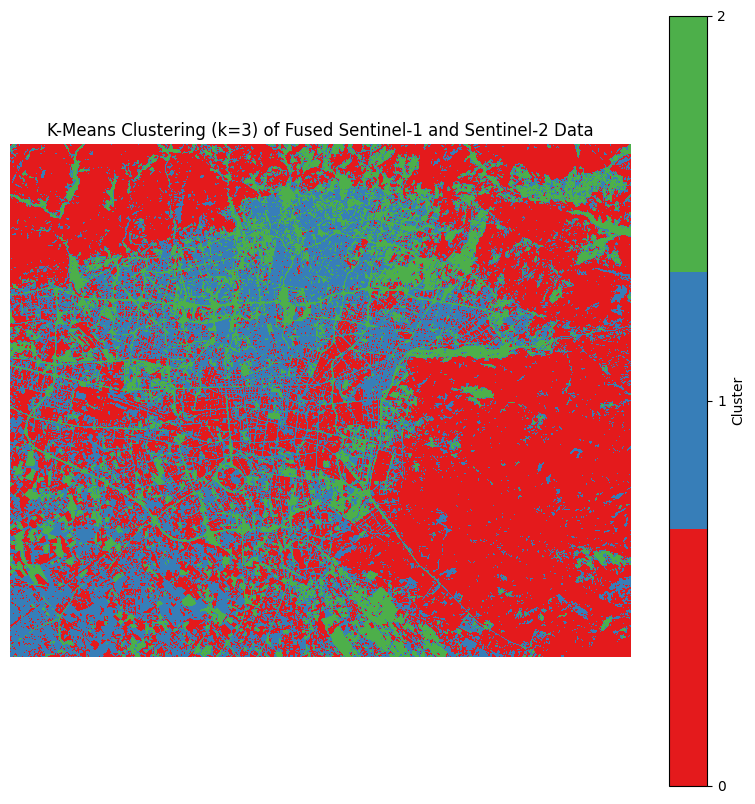

Clustered Image Shape for k=4: (3427, 4145)


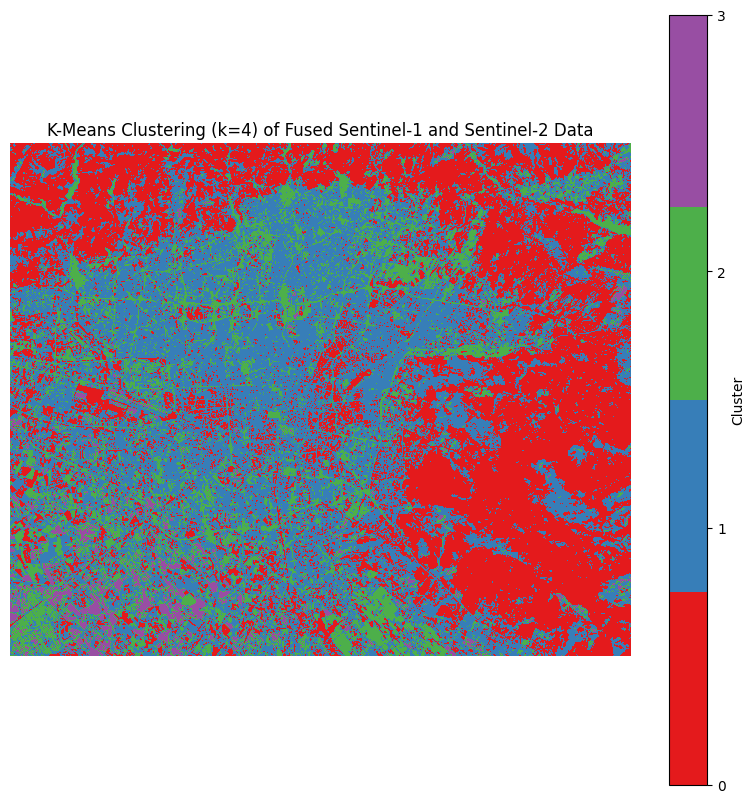

Clustered Image Shape for k=5: (3427, 4145)


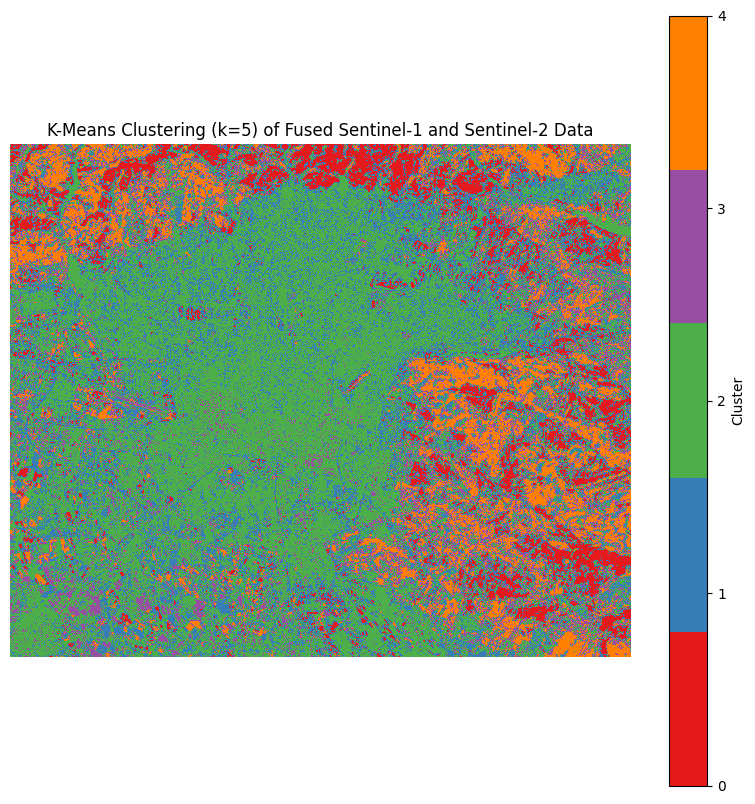

Clustered Image Shape for k=6: (3427, 4145)


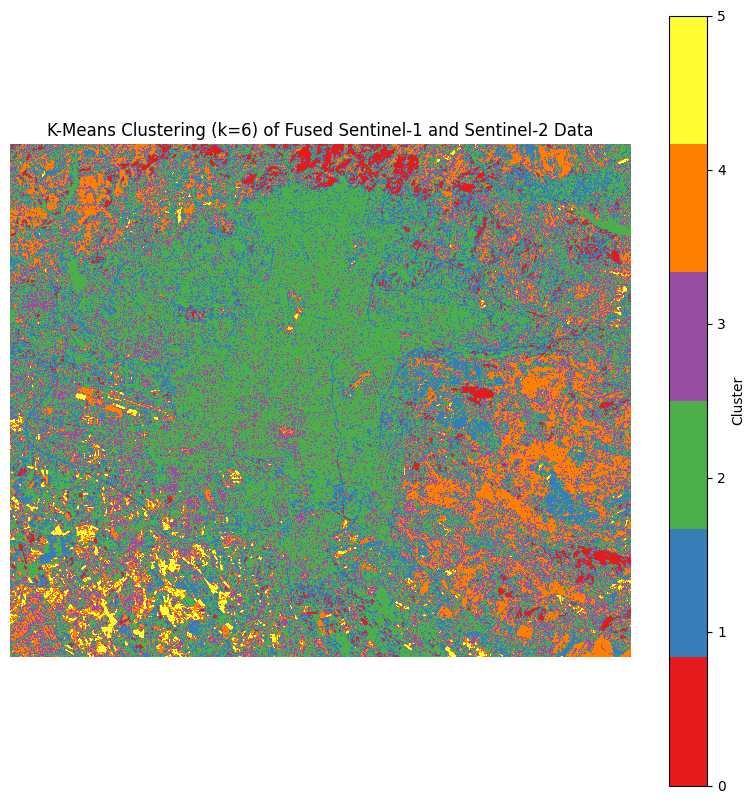

Clustered Image Shape for k=7: (3427, 4145)


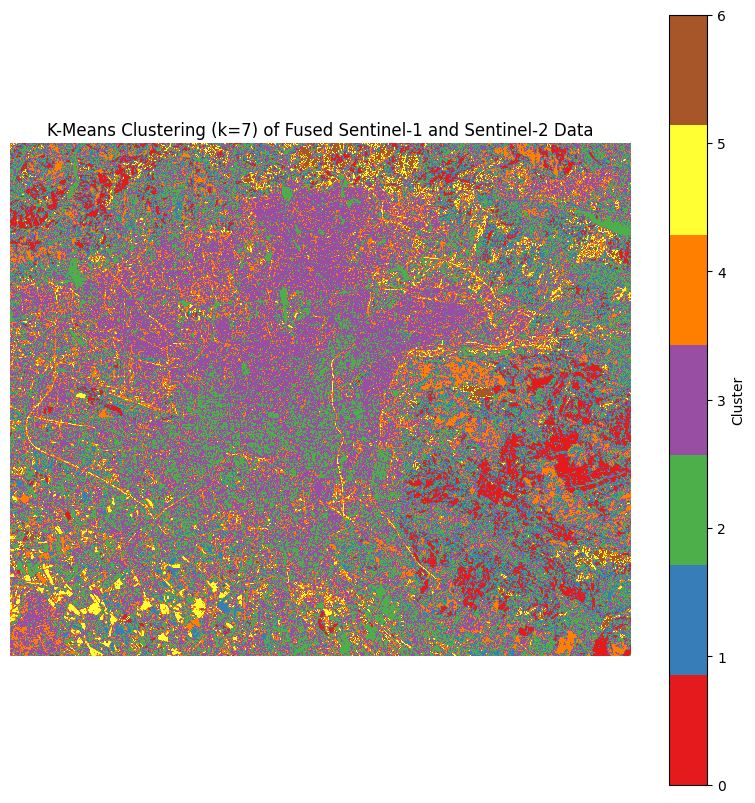

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# Extract bands from fused dataset
vv = fused_da.sel(band="vv").values
vh = fused_da.sel(band="vh").values
red = fused_da.sel(band="red").values
green = fused_da.sel(band="green").values
blue = fused_da.sel(band="blue").values

# Normalize all bands independently
vv_norm = (vv - np.nanmin(vv)) / (np.nanmax(vv) - np.nanmin(vv))
vh_norm = (vh - np.nanmin(vh)) / (np.nanmax(vh) - np.nanmin(vh))
red_norm = (red - np.nanmin(red)) / (np.nanmax(red) - np.nanmin(red))
green_norm = (green - np.nanmin(green)) / (np.nanmax(green) - np.nanmin(green))
blue_norm = (blue - np.nanmin(blue)) / (np.nanmax(blue) - np.nanmin(blue))

# Stack normalized bands into a 3D array (height, width, channels)
fused_data = np.dstack((vv_norm, vh_norm, red_norm, green_norm, blue_norm))

# Reshape into 2D array (pixels, channels)
pixels = fused_data.reshape(-1, 5)  # Flatten spatial dimensions
pixels = np.nan_to_num(pixels)  # Handle NaN values

# Define a color palette for up to 7 clusters
color_palette = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3",
    "#ff7f00", "#ffff33", "#a65628"
]

# Perform k-means clustering for k=3 to k=7
for k in range(3, 6):
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(pixels)
    labels = kmeans.labels_

    # Reshape labels back to the original image dimensions
    clustered_image = labels.reshape(fused_data.shape[0], fused_data.shape[1])
    print(f"Clustered Image Shape for k={k}: {clustered_image.shape}")

    # Create a colormap for the current number of clusters
    cmap = ListedColormap(color_palette[:k])

    # Plot the clustered image
    plt.figure(figsize=(10, 10))
    plt.imshow(clustered_image, cmap=cmap)
    plt.title(f"K-Means Clustering (k={k}) of Fused Sentinel-1 and Sentinel-2 Data")
    plt.axis("off")
    plt.colorbar(label="Cluster", ticks=range(k))
    plt.show()

Explained Variance Ratio by PCA: [0.96895472 0.02711276]
Clustered Image Shape for k=3: (3427, 4145)


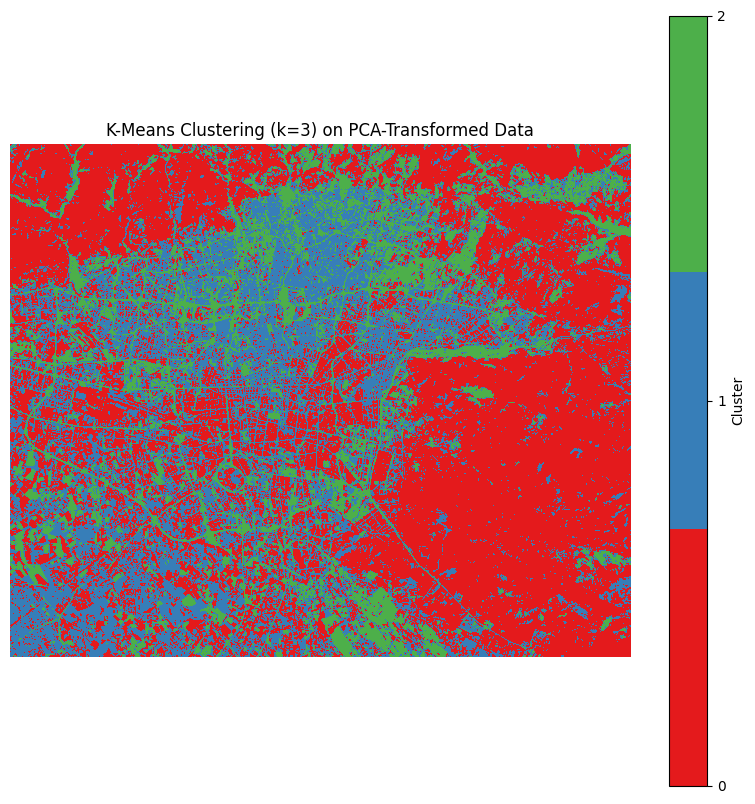

Clustered Image Shape for k=4: (3427, 4145)


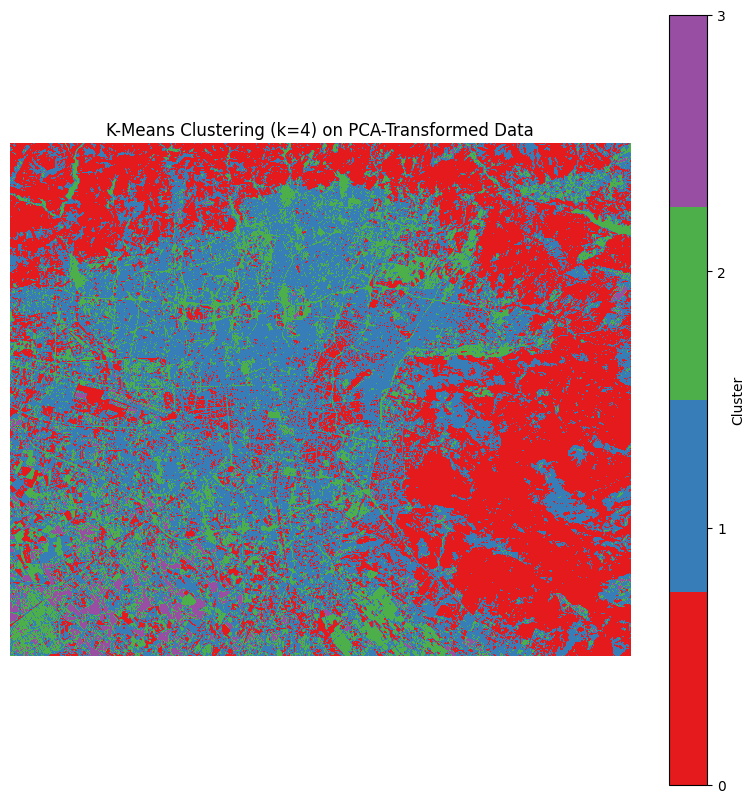

Clustered Image Shape for k=5: (3427, 4145)


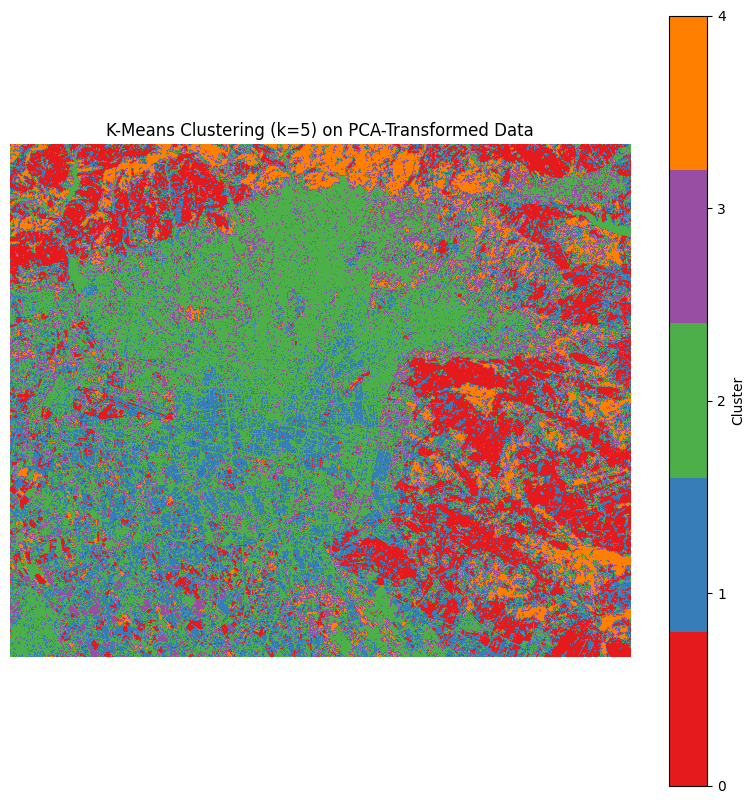

Clustered Image Shape for k=6: (3427, 4145)


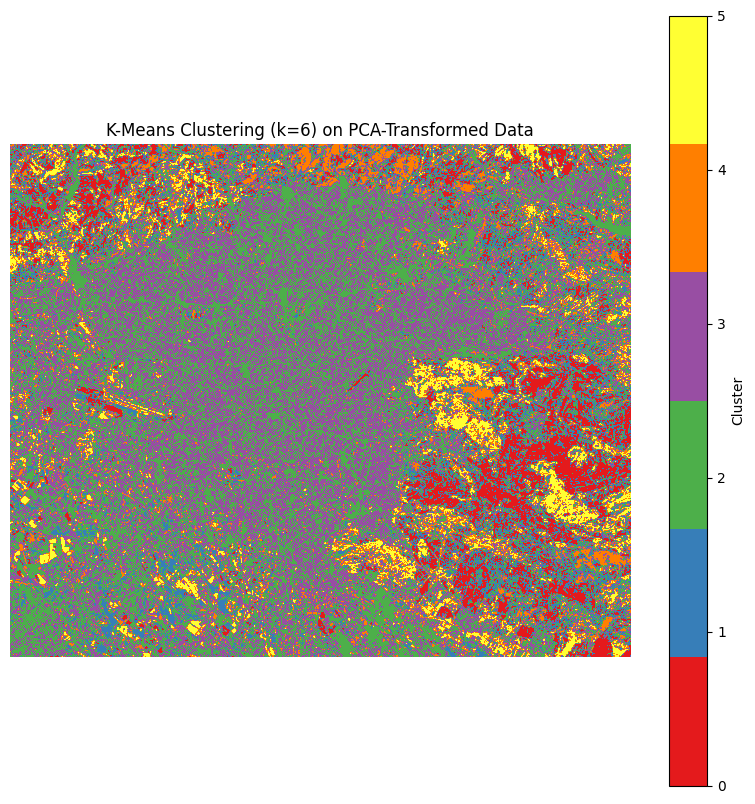

Clustered Image Shape for k=7: (3427, 4145)


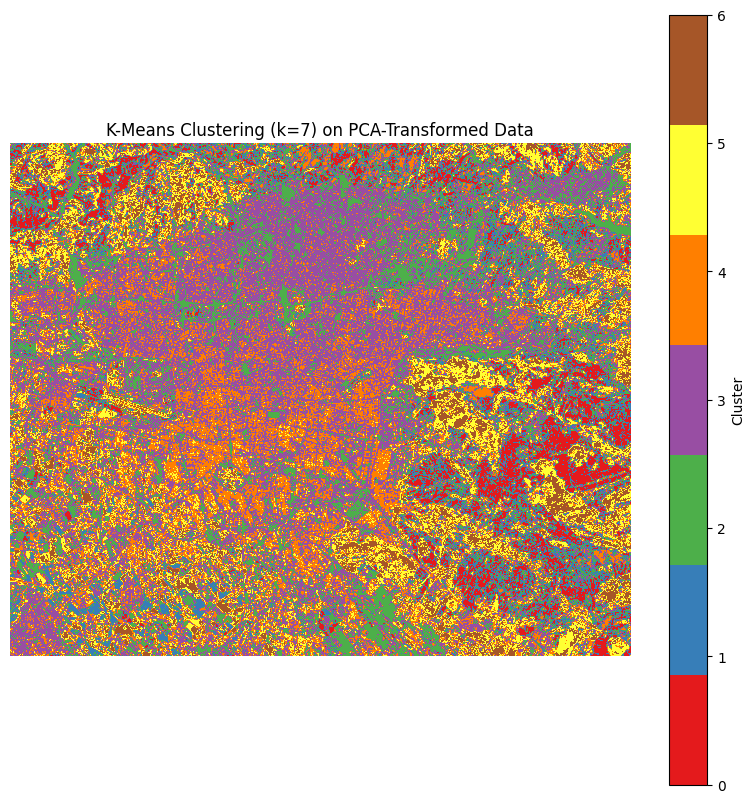

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)  # Reduce to 2 components for clustering
pixels_pca = pca.fit_transform(pixels)
print("Explained Variance Ratio by PCA:", pca.explained_variance_ratio_)

# Perform k-means clustering for k=3 to k=7 on PCA-transformed data
for k in range(3, 6):
    # Apply k-means clustering
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(pixels_pca)
    labels = kmeans.labels_

    # Reshape labels back to the original image dimensions
    clustered_image = labels.reshape(fused_data.shape[0], fused_data.shape[1])
    print(f"Clustered Image Shape for k={k}: {clustered_image.shape}")

    # Create a colormap for the current number of clusters
    cmap = ListedColormap(color_palette[:k])

    # Plot the clustered image
    plt.figure(figsize=(10, 10))
    plt.imshow(clustered_image, cmap=cmap)
    plt.title(f"K-Means Clustering (k={k}) on PCA-Transformed Data")
    plt.axis("off")
    plt.colorbar(label="Cluster", ticks=range(k))
    plt.show()

In [ ]:
# Search ESA WorldCover for the Tehran bounding box
worldcover_search = catalog.search(
    collections=["esa-worldcover"],
    bbox=[51.2196, 35.5384, 51.6759, 35.8456],
    datetime="2021-01-01/2023-12-31",  # Adjust for the most recent dataset
)
worldcover_items = worldcover_search.item_collection()

# Print Results
print(f"Returned {len(worldcover_items)} ESA WorldCover Items:")
if worldcover_items:
    for item in worldcover_items:
        print(item.id)
else:
    print("No ESA WorldCover items found.")

Returned 1 ESA WorldCover Items:
ESA_WorldCover_10m_2021_v200_N33E051


Unique Classes Found: [10. 20. 30. 40. 50. 60. 80. 90.]


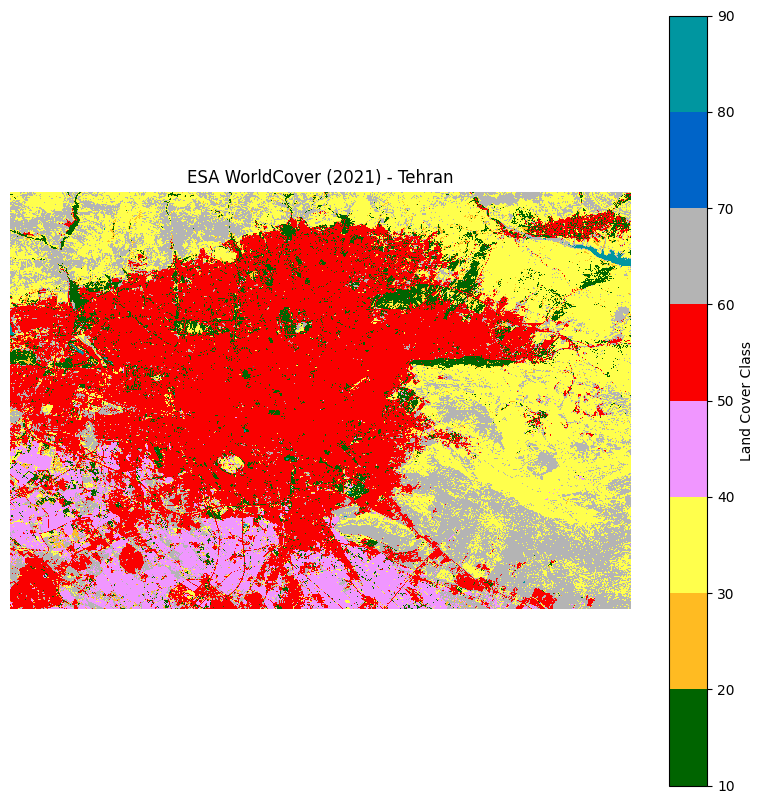

In [ ]:
import numpy as np
import rioxarray
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load the first WorldCover item
worldcover_url = worldcover_items[0].assets["map"].href

# Open the WorldCover dataset as an xarray DataArray
worldcover_da = rioxarray.open_rasterio(worldcover_url, masked=True)

# Clip to the bounding box (optional)
worldcover_clipped = worldcover_da.rio.clip_box(
    minx=51.2196, miny=35.5384, maxx=51.6759, maxy=35.8456
)

# Define a colormap based on the WorldCover legend
worldcover_classes = {
    10: "#006400",  # Tree cover
    20: "#ffbb22",  # Shrubland
    30: "#ffff4c",  # Grassland
    40: "#f096ff",  # Cropland
    50: "#fa0000",  # Built-up
    60: "#b4b4b4",  # Bare / sparse vegetation
    70: "#f0f0f0",  # Snow and ice
    80: "#0064c8",  # Permanent water bodies
    90: "#0096a0",  # Herbaceous wetland
    95: "#00cf75",  # Mangroves
    100: "#fae6a0",  # Moss and lichen
}

# Count unique land cover classes in the clipped dataset
unique_classes = np.unique(worldcover_clipped.values[~np.isnan(worldcover_clipped.values)])
print(f"Unique Classes Found: {unique_classes}")

# Create a color palette for the unique classes found
palette = [worldcover_classes.get(int(cls), "#000000") for cls in unique_classes]  # Default to black for unknown classes
cmap = ListedColormap(palette)

# Plot the WorldCover dataset
plt.figure(figsize=(10, 10))
plt.imshow(worldcover_clipped.squeeze(), cmap=cmap, interpolation="nearest")
plt.title("ESA WorldCover (2021) - Tehran")
plt.axis("off")
plt.colorbar(label="Land Cover Class")
plt.show()